# import bibliotek i definicja potrzebnych funkcji


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


def mat2pix(m, n, dx, dy, x, y):
    """
    m, n - size of the image in pixels
    dx, dy - size of the image in math coordinates
    x, y - math coordinates of the point
    """
    transformMatrix = np.array([[1 / dx, 0, 0.5 * m], [0, -1 / dy, 0.5 * n], [0, 0, 1]])

    pixelCoords = np.dot(transformMatrix, np.array([x, y, 1]))
    # KONWERSJA DO INT jest ważna dla funkcji cv2.fillPoly
    # poza tym tak jest bardziej logicznie, ponieważ współrzędne pikseli powinny być liczbami całkowitymi
    px = int(round(pixelCoords[0] / pixelCoords[2]))
    py = int(round(pixelCoords[1] / pixelCoords[2]))
    return px, py


def pix2mat(m, n, dx, dy, u, v):
    transformMatrix = np.array(
        [[dx, 0, -0.5 * m * dx], [0, -dy, 0.5 * n * dy], [0, 0, 1]]
    )

    mathCords = np.dot(transformMatrix, np.array([u, v, 1]))
    return (mathCords[0] / mathCords[2]), (mathCords[1] / mathCords[2])


def distance2plane(point, A, b, c, d):
    """
    Oblicza odległość punktu 3D od płaszczyzny oraz wyznacza punkt na płaszczyźnie,
    który jest rzutem prostopadłym danego punktu.

    Argumenty:
    point : array-like o długości 3
        Punkt 3D w postaci [x, y, z].
    A, b, c, d : float
        Współczynniki równania płaszczyzny:
        A*x + b*y + c*z + d = 0.

    Zwraca:
    tuple[float, np.ndarray]
        - float: Nieujemna odległość punktu od płaszczyzny.
        - np.ndarray: Punkt 3D na płaszczyźnie (rzut prostopadły danego punktu).

    Wyjątki:
    ValueError
        Gdy wektor normalny płaszczyzny ma długość zero.
    """
    point = np.asarray(point, dtype=float)
    x, y, z = point

    mianownik = A**2 + b**2 + c**2

    if np.isclose(mianownik, 0.0):
        raise ValueError(
            "Nieprawidłowa płaszczyzna: A, b, c nie mogą być jednocześnie zerowe."
        )

    licznik = A * x + b * y + c * z + d

    # Parametr t dla punktu na płaszczyźnie (rzut prostopadły)
    t = -licznik / mianownik

    # Współrzędne punktu na płaszczyźnie
    x_plane = x + t * A
    y_plane = y + t * b
    z_plane = z + t * c
    plane_point = np.array([x_plane, y_plane, z_plane])

    # Odległość
    distance = np.abs(licznik) / np.sqrt(mianownik)

    return float(distance), plane_point


## Definicja typów dla łatwiejszego pisania kodu


In [2]:
class Point:
    def __init__(self, x, y, z):
        self.coords = np.array([x, y, z])

    def __getitem__(self, index):
        return self.coords[index]


class Triangle:
    def __init__(self, p1: Point, p2: Point, p3: Point):
        self.p1 = p1
        self.p2 = p2
        self.p3 = p3
        self.epsilon = 1


class Light:
    def __init__(self, position: Point, intensity: float):
        self.position = position
        self.intensity = intensity

# Zadanie 1 i 2

Modele oświetlenia Phonga i Lamebrta dla sceny


In [3]:
def DrawTriangleWithLambert(
    Image, Triangle, Lights, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, AMBIENT_LIGHT
):

    imgCopy = Image.copy()
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]

    # aby skrócić kod, korzystam z funkcji fillPoly z biblioteki cv2 zamiast z ręcznie pisanych funkcji
    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))

    # plt.imshow(imgCopy)
    # plt.axis("off")
    # plt.title(
    #     f"Maska trójkąta: {Triangle.p1.coords}, {Triangle.p2.coords}, {Triangle.p3.coords}"
    # )
    # plt.show()
    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )

    # znormalizu wektor normalny
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)

    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            final_intensity = AMBIENT_LIGHT
            # pomijamy piksele nie należące do trójkąta
            if not np.all(imgCopy[y, x] == 255):
                continue

            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            if np.isclose(C, 0.0):
                continue
            z_plane = -(A * X_world + B * Y_world + D) / C
            plane_point = np.array([X_world, Y_world, z_plane])

            for light in Lights:
                light_vector = light.position.coords - plane_point
                # podobno najlepsza metoda na obliczenie długości wektora w pythonie (Google)
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance

                angle_cos = np.dot(triangle_normal, light_vector_normalized)
                final_intensity += (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * max(angle_cos, 0)
                )
            final_intensity = max(0, min(255, int(final_intensity)))
            Image[y, x] = (final_intensity, final_intensity, final_intensity)

    return Image


In [4]:
def DrawTriangleWithPhong(
    Image,
    Triangle,
    Lights,
    ROZDZIELCZOSC_X,
    ROZDZIELCZOSC_Y,
    DX,
    DY,
    AMBIENT_LIGHT,
    eye_position,
):

    imgCopy = np.zeros_like(Image)
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]

    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))
    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )

    # znormalizu wektor normalny
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)

    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            final_intensity = AMBIENT_LIGHT
            # pomijamy piksele nie należące do trójkąta
            if not imgCopy[y, x][0] == 255:
                continue

            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            if np.isclose(C, 0.0):
                continue
            z_plane = -(A * X_world + B * Y_world + D) / C
            plane_point = np.array([X_world, Y_world, z_plane])

            for light in Lights:
                light_vector = light.position.coords - plane_point
                # podobno najlepsza metoda na obliczenie długości wektora w pythonie (Google)
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance

                angle_cos = np.dot(triangle_normal, light_vector_normalized)

                labmert_diffuse = (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * max(angle_cos, 0)
                )

                reflection_vector = (
                    2 * angle_cos * triangle_normal - light_vector_normalized
                )

                eye_vector = eye_position.coords - plane_point
                eye_vector_normalized = eye_vector / np.linalg.norm(eye_vector)
                specular_dot = np.dot(reflection_vector, eye_vector_normalized)
                specular_contribution = (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * (max(specular_dot, 0) ** 15)
                )

                final_intensity += labmert_diffuse + specular_contribution

            final_intensity = max(0, min(255, int(final_intensity)))
            Image[y, x] = (final_intensity, final_intensity, final_intensity)

    return Image

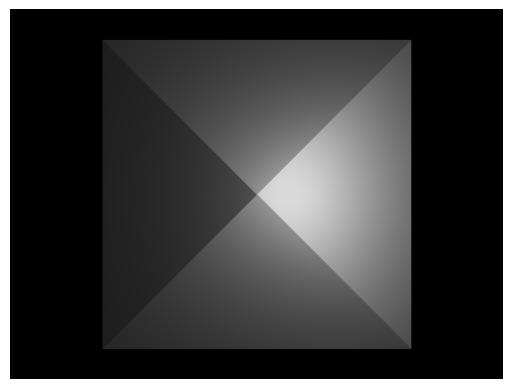

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

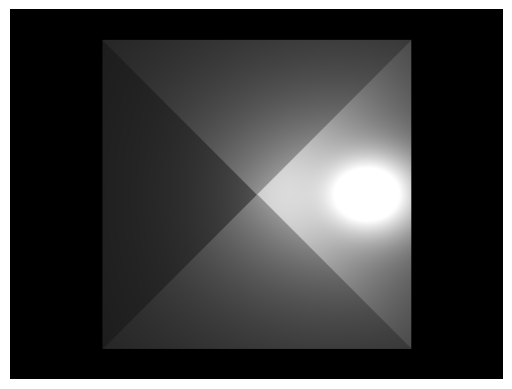

In [5]:
Triangles = [
    Triangle(Point(0, 0, 10), Point(20, 20, 20), Point(20, -20, 20)),
    Triangle(Point(0, 0, 10), Point(20, -20, 20), Point(-20, -20, 20)),
    Triangle(Point(0, 0, 10), Point(-20, -20, 20), Point(-20, 20, 20)),
    Triangle(Point(0, 0, 10), Point(-20, 20, 20), Point(20, 20, 20)),
]

Lights = [Light(Point(10, 0, 0), 235)]

Eye_position = Point(65, 0, 0)

ROZDZIELCZOSC_X = 640
ROZDZIELCZOSC_Y = 480
DX = 0.1
DY = 0.1

AMBIENT_LIGHT = 20

image = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)
imagePhong = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)

# for each triangle add it to the scene with light calculated
for triangle in Triangles:
    image = DrawTriangleWithLambert(
        image, triangle, Lights, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, AMBIENT_LIGHT
    )
    imagePhong = DrawTriangleWithPhong(
        imagePhong,
        triangle,
        Lights,
        ROZDZIELCZOSC_X,
        ROZDZIELCZOSC_Y,
        DX,
        DY,
        AMBIENT_LIGHT,
        Eye_position,
    )

plt.imshow(image)
plt.axis("off")
plt.show()

plt.imshow(imagePhong)
plt.axis("off")


# Zadanie 3 - cieniowanie stałe


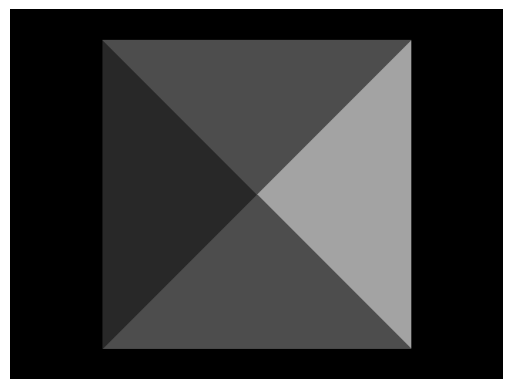

In [6]:
def cieniowanie_stale(
    Image, Triangle, Lights, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, AMBIENT_LIGHT
):

    imgCopy = Image.copy()
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]

    # aby skrócić kod, korzystam z funkcji fillPoly z biblioteki cv2 zamiast z ręcznie pisanych funkcji
    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))

    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )

    # znormalizu wektor normalny
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)

    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # oblicz intensywnośc światła dla środka trójkąta
    center_point = (Triangle.p1.coords + Triangle.p2.coords + Triangle.p3.coords) / 3

    final_intensity = AMBIENT_LIGHT

    # X_world, Y_world = pix2mat(
    #     ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, center_point[0], center_point[1]
    # )
    # distance, plane_point = distance2plane((X_world, Y_world, 0), A, B, C, D)

    for light in Lights:
        light_vector = light.position.coords - center_point
        # podobno najlepsza metoda na obliczenie długości wektora w pythonie (Google)
        light_distance = np.linalg.norm(light_vector)
        light_vector_normalized = light_vector / light_distance

        angle_cos = np.dot(triangle_normal, light_vector_normalized)
        final_intensity += (
            light.intensity / (1 + 0.001 * light_distance**2) * max(angle_cos, 0)
        )
    final_intensity = max(0, min(255, int(final_intensity)))

    # zaaplikuj obliczone światło do wszystkich pikseli trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            # pomijamy piksele nie należące do trójkąta
            if not imgCopy[y, x][0] == 255:
                continue
            Image[y, x] = (final_intensity, final_intensity, final_intensity)

    return Image


image_stale_cienie = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)

# for each triangle add it to the scene with light calculated
for triangle in Triangles:
    image_stale_cienie = cieniowanie_stale(
        image_stale_cienie,
        triangle,
        Lights,
        ROZDZIELCZOSC_X,
        ROZDZIELCZOSC_Y,
        DX,
        DY,
        AMBIENT_LIGHT,
    )

plt.imshow(image_stale_cienie)
plt.axis("off")
plt.show()

# Zadanie 4 - cieniowanie Gourauda dla oryginalnych wektorów normalnych w narożnikach


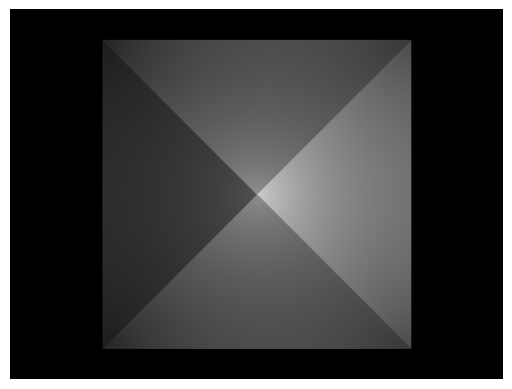

In [7]:
def cieniowanieGouraudOGNormals(
    Image, Triangle, Lights, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, AMBIENT_LIGHT
):

    imgCopy = Image.copy()
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]

    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))

    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)
    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # ZAKŁADAM ORYGINALNE WEKTORY NORMALNE W NAROŻNIKACH
    # CO ZA TYM IDZIE SĄ ONE RÓWNE WEKTOROWI NORMALNEMU PŁASZCZYZNY TRÓJKĄTA

    # OBliczam oświatło w narożnikach:
    swiatlo_naroznikow = []
    for point in [Triangle.p1.coords, Triangle.p2.coords, Triangle.p3.coords]:
        final_intensity = AMBIENT_LIGHT
        for light in Lights:
            light_vector = light.position.coords - point
            light_distance = np.linalg.norm(light_vector)
            light_vector_normalized = light_vector / light_distance

            angle_cos = np.dot(triangle_normal, light_vector_normalized)
            final_intensity += (
                light.intensity / (1 + 0.001 * light_distance**2) * max(angle_cos, 0)
            )

        final_intensity = max(0, min(255, int(final_intensity)))

        # indeks naroznika jest taki jak indeks punktów w trójkącie
        swiatlo_naroznikow.append(final_intensity)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            # pomijamy piksele nie należące do trójkąta
            if not np.all(imgCopy[y, x] == 255):
                continue
            # distance, plane_point = distance2plane((X_world, Y_world, 0), A, B, C, D)
            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            if np.isclose(C, 0.0):
                continue
            z_plane = -(A * X_world + B * Y_world + D) / C
            plane_point = np.array([X_world, Y_world, z_plane])

            # jeśli punkt jest narożnikiem to jego intensywność jest obliczona
            # liczenie jej tym samym wzorem skutuje dzieleniem przez 0
            if np.allclose(plane_point, Triangle.p1.coords):
                Image[y, x] = (swiatlo_naroznikow[0],) * 3
                continue
            elif np.allclose(plane_point, Triangle.p2.coords):
                Image[y, x] = (swiatlo_naroznikow[1],) * 3
                continue
            elif np.allclose(plane_point, Triangle.p3.coords):
                Image[y, x] = (swiatlo_naroznikow[2],) * 3
                continue
            # wyliczam intensywność światła dla punktu na podstawie jego odległości od narożników
            final_intensity = (
                swiatlo_naroznikow[0] / np.linalg.norm(plane_point - Triangle.p1.coords)
                + swiatlo_naroznikow[1]
                / np.linalg.norm(plane_point - Triangle.p2.coords)
                + swiatlo_naroznikow[2]
                / np.linalg.norm(plane_point - Triangle.p3.coords)
            ) / (
                1 / np.linalg.norm(plane_point - Triangle.p1.coords)
                + 1 / np.linalg.norm(plane_point - Triangle.p2.coords)
                + 1 / np.linalg.norm(plane_point - Triangle.p3.coords)
            )

            final_intensity = max(0, min(255, int(final_intensity)))
            Image[y, x] = (final_intensity, final_intensity, final_intensity)

    return Image


image_gouraud = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)
for triangle in Triangles:
    image_gouraud = cieniowanieGouraudOGNormals(
        image_gouraud,
        triangle,
        Lights,
        ROZDZIELCZOSC_X,
        ROZDZIELCZOSC_Y,
        DX,
        DY,
        AMBIENT_LIGHT,
    )

plt.figure()
plt.imshow(image_gouraud)
plt.axis("off")
plt.show()

# Zadanie 5 - cieniowanie Gourauda dla wektorów normalnych obliczonych jako średnia z normalnych trójkątów sąsiadujących z danym wierzchołkiem


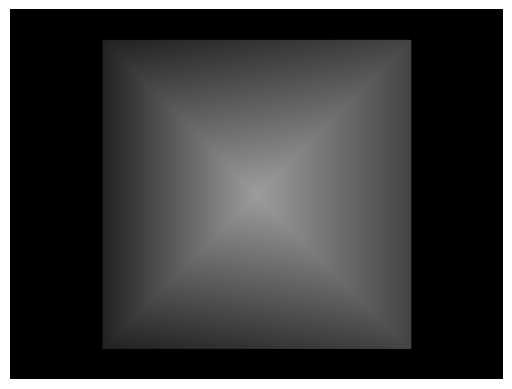

In [12]:
def cieniowanieGouraudCalculatedNormals(
    Image,
    Triangle,
    Lights,
    ROZDZIELCZOSC_X,
    ROZDZIELCZOSC_Y,
    DX,
    DY,
    AMBIENT_LIGHT,
    Normals,
):
    """
    Normals - ważne żeby kolejność wektorów normalnych odpowiadała kolejności wierzchołków
      trójkąta
    """

    imgCopy = Image.copy()
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]
    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))

    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)
    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # ZAKŁADAM ORYGINALNE WEKTORY NORMALNE W NAROŻNIKACH
    # CO ZA TYM IDZIE SĄ ONE RÓWNE WEKTOROWI NORMALNEMU PŁASZCZYZNY TRÓJKĄTA

    # OBliczam oświatło w narożnikach:
    swiatlo_naroznikow = []
    for point, point_normal in zip(
        [Triangle.p1.coords, Triangle.p2.coords, Triangle.p3.coords], Normals
    ):
        # distance, plane_point = distance2plane((point[0], point[1], 0), A, B, C, D)

        final_intensity = AMBIENT_LIGHT
        for light in Lights:
            light_vector = light.position.coords - point
            light_distance = np.linalg.norm(light_vector)
            light_vector_normalized = light_vector / light_distance

            #
            angle_cos = np.dot(point_normal, light_vector_normalized)
            final_intensity += (
                light.intensity / (1 + 0.001 * light_distance**2) * max(angle_cos, 0)
            )

        final_intensity = max(0, min(255, int(final_intensity)))

        # indeks naroznika jest taki jak indeks punktów w trójkącie
        swiatlo_naroznikow.append(final_intensity)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            # pomijamy piksele nie należące do trójkąta
            if not np.all(imgCopy[y, x] == 255):
                continue

            final_intensity = AMBIENT_LIGHT
            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            if np.isclose(C, 0.0):
                continue
            z_plane = -(A * X_world + B * Y_world + D) / C
            plane_point = np.array([X_world, Y_world, z_plane])

            # jeśli punkt jest narożnikiem to jego intensywność jest obliczona
            # liczenie jej tym samym wzorem skutuje dzieleniem przez 0
            if np.allclose(plane_point, Triangle.p1.coords):
                Image[y, x] = (swiatlo_naroznikow[0],) * 3
                continue
            elif np.allclose(plane_point, Triangle.p2.coords):
                Image[y, x] = (swiatlo_naroznikow[1],) * 3
                continue
            elif np.allclose(plane_point, Triangle.p3.coords):
                Image[y, x] = (swiatlo_naroznikow[2],) * 3
                continue

            # wyliczam intensywność światła dla punktu na podstawie współrzędnych barycentrycznych
            x1, y1 = Triangle.p1.coords[0], Triangle.p1.coords[1]
            x2, y2 = Triangle.p2.coords[0], Triangle.p2.coords[1]
            x3, y3 = Triangle.p3.coords[0], Triangle.p3.coords[1]
            px, py = plane_point[0], plane_point[1]

            mianownik = (y2 - y3) * (x1 - x3) + (x3 - x2) * (y1 - y3)
            if np.isclose(mianownik, 0.0):
                continue

            w1 = ((y2 - y3) * (px - x3) + (x3 - x2) * (py - y3)) / mianownik
            w2 = ((y3 - y1) * (px - x3) + (x1 - x3) * (py - y3)) / mianownik
            w3 = 1.0 - w1 - w2

            final_intensity = (
                swiatlo_naroznikow[0] * w1
                + swiatlo_naroznikow[1] * w2
                + swiatlo_naroznikow[2] * w3
            )

            # Interpolacja za pomocą odległości od narozników w przestrzeni OBRAZU
            # t1P1x, t1P1y = mat2pix(
            #     ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
            # )
            # t1P2x, t1P2y = mat2pix(
            #     ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
            # )
            # t1P3x, t1P3y = mat2pix(
            #     ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
            # )

            # final_intensity = (
            #     swiatlo_naroznikow[0]
            #     / np.linalg.norm(np.array([x, y]) - np.array([t1P1x, t1P1y]))
            #     + swiatlo_naroznikow[1]
            #     / np.linalg.norm(np.array([x, y]) - np.array([t1P2x, t1P2y]))
            #     + swiatlo_naroznikow[2]
            #     / np.linalg.norm(np.array([x, y]) - np.array([t1P3x, t1P3y]))
            # ) / (
            #     1 / np.linalg.norm(np.array([x, y]) - np.array([t1P1x, t1P1y]))
            #     + 1 / np.linalg.norm(np.array([x, y]) - np.array([t1P2x, t1P2y]))
            #     + 1 / np.linalg.norm(np.array([x, y]) - np.array([t1P3x, t1P3y]))
            # )

            final_intensity = max(0, min(255, int(final_intensity)))
            Image[y, x] = (final_intensity, final_intensity, final_intensity)

    return Image


def CalculateNormals(Triangle: Triangle, PossibleAdjacentTriangles: list[Triangle]):
    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)
    calculated_normals = []

    for point in [Triangle.p1.coords, Triangle.p2.coords, Triangle.p3.coords]:
        final_normal = triangle_normal.copy()
        adjacent_count = 0
        for adjacentTriangle in PossibleAdjacentTriangles:
            # pomijamy ten sam trójkąt, nie może sąsiadywać sam ze sobą
            if adjacentTriangle == Triangle:
                continue
            # jeśli którykolwiek z punktów trójkąta jest taki sam jak analizowany punkt
            # to ten trójkąt jest sąsiadujący
            if any(
                np.array_equal(adjacent_point, point)
                for adjacent_point in [
                    adjacentTriangle.p1.coords,
                    adjacentTriangle.p2.coords,
                    adjacentTriangle.p3.coords,
                ]
            ):
                adjacentPointNormal = np.cross(
                    adjacentTriangle.p2.coords - adjacentTriangle.p1.coords,
                    adjacentTriangle.p3.coords - adjacentTriangle.p1.coords,
                )
                adjacentPointNormal = adjacentPointNormal / np.linalg.norm(
                    adjacentPointNormal
                )
                final_normal += adjacentPointNormal
                adjacent_count += 1

        final_normal = final_normal / np.linalg.norm(final_normal)
        calculated_normals.append(final_normal)
    return calculated_normals


image_gouraud = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)
for triangle in Triangles:
    image_gouraud = cieniowanieGouraudCalculatedNormals(
        image_gouraud,
        triangle,
        Lights,
        ROZDZIELCZOSC_X,
        ROZDZIELCZOSC_Y,
        DX,
        DY,
        AMBIENT_LIGHT,
        CalculateNormals(triangle, Triangles),
    )

plt.figure()
plt.imshow(image_gouraud)
plt.axis("off")
plt.show()

# Zadanie 6 - ceiniowanie Phonga dla wektorów normalnych obliczonych jako średnia z normalnych trójkątów sąsiadujących z danym wierzchołkiem

Model oświetlenia w wierzchołkach - model Lamberta


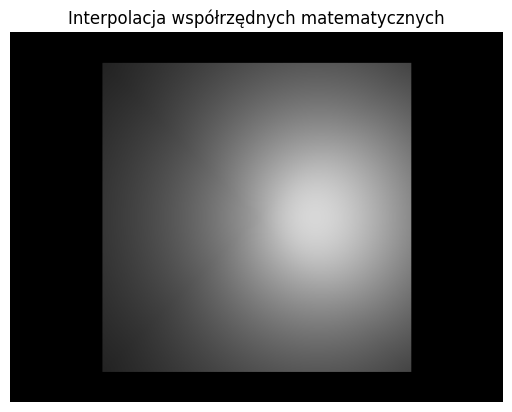

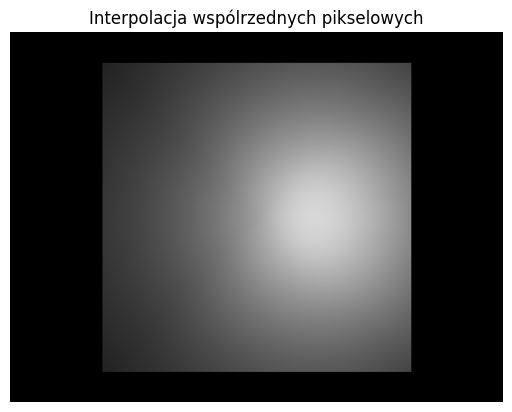

In [9]:
def cieniowaniePhonga(
    Image,
    Triangle,
    Lights,
    ROZDZIELCZOSC_X,
    ROZDZIELCZOSC_Y,
    DX,
    DY,
    AMBIENT_LIGHT,
    Normals,
    tryb_interpolacji,
):
    imgCopy = Image.copy()
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]
    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))

    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            if not np.all(imgCopy[y, x] == 255):
                continue

            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            if np.isclose(C, 0.0):
                continue
            z_plane = -(A * X_world + B * Y_world + D) / C
            plane_point = np.array([X_world, Y_world, z_plane])

            if tryb_interpolacji == "piksele":
                p1x, p1y = mat2pix(
                    ROZDZIELCZOSC_X,
                    ROZDZIELCZOSC_Y,
                    DX,
                    DY,
                    Triangle.p1[0],
                    Triangle.p1[1],
                )
                p2x, p2y = mat2pix(
                    ROZDZIELCZOSC_X,
                    ROZDZIELCZOSC_Y,
                    DX,
                    DY,
                    Triangle.p2[0],
                    Triangle.p2[1],
                )
                p3x, p3y = mat2pix(
                    ROZDZIELCZOSC_X,
                    ROZDZIELCZOSC_Y,
                    DX,
                    DY,
                    Triangle.p3[0],
                    Triangle.p3[1],
                )
                px, py = x, y
                mianownik = (p2y - p3y) * (p1x - p3x) + (p3x - p2x) * (p1y - p3y)
            else:
                p1x, p1y = Triangle.p1.coords[0], Triangle.p1.coords[1]
                p2x, p2y = Triangle.p2.coords[0], Triangle.p2.coords[1]
                p3x, p3y = Triangle.p3.coords[0], Triangle.p3.coords[1]
                px, py = plane_point[0], plane_point[1]
                mianownik = (p2y - p3y) * (p1x - p3x) + (p3x - p2x) * (p1y - p3y)

            if np.isclose(mianownik, 0.0):
                continue

            w1 = ((p2y - p3y) * (px - p3x) + (p3x - p2x) * (py - p3y)) / mianownik
            w2 = ((p3y - p1y) * (px - p3x) + (p1x - p3x) * (py - p3y)) / mianownik
            w3 = 1.0 - w1 - w2

            normal_punktu = Normals[0] * w1 + Normals[1] * w2 + Normals[2] * w3
            normal_punktu = normal_punktu / np.linalg.norm(normal_punktu)

            final_intensity = AMBIENT_LIGHT
            for light in Lights:
                light_vector = light.position.coords - plane_point
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance

                angle_cos = np.dot(normal_punktu, light_vector_normalized)
                final_intensity += (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * max(angle_cos, 0)
                )

            final_intensity = max(0, min(255, int(final_intensity)))
            Image[y, x] = (final_intensity, final_intensity, final_intensity)

    return Image


image_phong_swiat = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)
image_phong_piksele = np.zeros((ROZDZIELCZOSC_Y, ROZDZIELCZOSC_X, 3), dtype=np.uint8)
for triangle in Triangles:
    normalne = CalculateNormals(triangle, Triangles)
    image_phong_swiat = cieniowaniePhonga(
        image_phong_swiat,
        triangle,
        Lights,
        ROZDZIELCZOSC_X,
        ROZDZIELCZOSC_Y,
        DX,
        DY,
        AMBIENT_LIGHT,
        normalne,
        "swiat",
    )
    image_phong_piksele = cieniowaniePhonga(
        image_phong_piksele,
        triangle,
        Lights,
        ROZDZIELCZOSC_X,
        ROZDZIELCZOSC_Y,
        DX,
        DY,
        AMBIENT_LIGHT,
        normalne,
        "piksele",
    )

plt.figure()
plt.imshow(image_phong_swiat)
plt.title("Interpolacja współrzędnych matematycznych")
plt.axis("off")
plt.show()

plt.figure()
plt.imshow(image_phong_piksele)
plt.title("Interpolacja wspólrzednych pikselowych")
plt.axis("off")
plt.show()